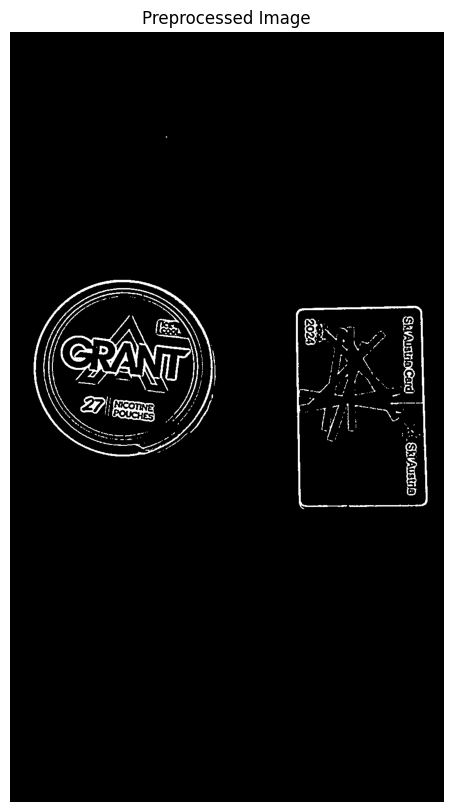

In [65]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to calculate the midpoint between two points
def midpoint(ptA, ptB):
    return ((ptA[0] + ptB[0]) * 0.5, (ptA[1] + ptB[1]) * 0.5)

# Load the image
image = cv2.imread("test7.jpg")

# Convert the image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# plt.imshow(cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR))  
# plt.title("Measured Sheet and Reference Object")
# plt.axis('off')  
# plt.show()

# Apply Gaussian blur to reduce noise
blurred = cv2.GaussianBlur(gray, (7, 7), 0)




# Apply Adaptive Thresholding
thresh = cv2.adaptiveThreshold(
    blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, 9, 3)



morphed = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, (1,1))

# Display the preprocessed image
plt.figure(figsize=(10, 10))
plt.imshow(morphed, cmap='gray')
plt.axis('off')
plt.title("Preprocessed Image")
plt.show()

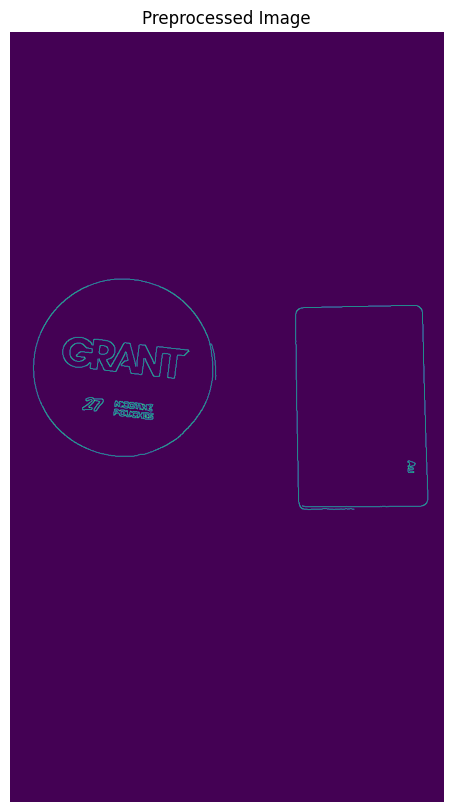

In [70]:
# Detect edges using Canny edge detection with dynamic thresholds
sigma = 0.6
v = np.median(blurred)
lower = int(max(0, (1.0 - sigma) * v))
upper = int(min(255, (1.0 + sigma) * v))
edges = cv2.Canny(blurred, lower, upper)


# Display the preprocessed image
plt.figure(figsize=(10, 10))
plt.imshow(edges)
plt.axis('off')
plt.title("Preprocessed Image")
plt.show()

In [67]:
# Find contours in the edged image
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)



Pixel per cm ratio: 12.167562893893727


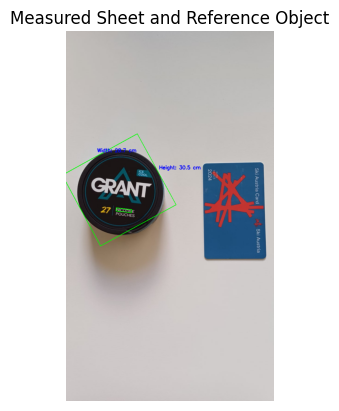

Image saved as 'measured_output.jpg'


In [68]:




# Sort contours in ascending order to focus on the smallest object first (e.g., reference card)
contours = sorted(contours, key=cv2.contourArea)

# Known width of the reference object (e.g., credit card width in cm)
known_width = 5.5  # Adjust this as needed for the reference object

reference_found = False
sheet_measured = False

# Loop over the contours to find the reference object (smallest) and the target object (sheet)
for contour in contours:
    # Ignore very small contours that are likely noise
    if cv2.contourArea(contour) < 100:
        continue

    # Compute the bounding box of the contour
    box = cv2.minAreaRect(contour)
    box = cv2.boxPoints(box)  # Get 4 corner points of the bounding box
    box = np.array(box, dtype="int")

    # Draw the bounding box on the image
    cv2.drawContours(image, [box], 0, (0, 255, 0), 2)



    # Compute the midpoints for the width and height of the bounding box
    (tl, tr, br, bl) = box
    (tltrX, tltrY) = midpoint(tl, tr)
    (blbrX, blbrY) = midpoint(bl, br)
    (tlblX, tlblY) = midpoint(tl, bl)
    (trbrX, trbrY) = midpoint(tr, br)

    # Calculate the Euclidean distance between the midpoints (width and height)
    width = np.sqrt(((tltrX - blbrX) ** 2) + ((tltrY - blbrY) ** 2))
    height = np.sqrt(((tlblX - trbrX) ** 2) + ((tlblY - trbrY) ** 2))

    # Assuming the first detected object is the reference object (smallest)
    if not reference_found:
        # Compute the pixel-per-metric ratio (pixels per cm) based on the smaller reference object
        scale = width / known_width
        reference_found = True
        print(f"Pixel per cm ratio: {scale}")
    elif reference_found and not sheet_measured:
        # Measure the sheet (target object, which is larger)
        sheet_width_cm = width / scale
        sheet_height_cm = height / scale

        # Display the measurements on the image
        cv2.putText(image, f"Width: {sheet_width_cm:.1f} cm", (int(tltrX - 10), int(tltrY - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
        cv2.putText(image, f"Height: {sheet_height_cm:.1f} cm", (int(trbrX + 10), int(trbrY)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
        sheet_measured = True
        break  # Stop after measuring the sheet

# Show the final output image
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for proper color display
plt.title("Measured Sheet and Reference Object")
plt.axis('off')  
plt.show()

# Save the final output image
cv2.imwrite("measured_output.jpg", image)
print("Image saved as 'measured_output.jpg'")


